**Automatic ML - DS_C8_SC1**

---

**Reto: Predicción de candidatos elegibles para promoción laboral**

NOMBRE DEL PARTICIPANTE: ------------------------------( LLENAR )------------------------------

In [ ]:
# Es importante instalar todas las librerías inicialmente, porque Colab pide reiniciar el entorno de ejecución
# Cuando esto ocurra, es NECESARIO volver a ejecutar esta misma celda, ya que el reinicio borra las librerías instaladas en memoria
!pip install fg-data-profiling
!pip install sweetviz
!pip install pycaret

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.3/400.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 75.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 3.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pmda

In [ ]:
# Por un problema de incompatibilidad con Python 3.12, se sobrescribe el archivo __init__.py de PyCaret
# Con esto se desactiva la validación de versión y permite su uso en este entorno
content = '''import sys
from pycaret.utils._show_versions import show_versions

version_ = "3.3.2"
__version__ = version_
__all__ = ["show_versions", "__version__"]

if sys.version_info < (3, 9):
    raise RuntimeError(
        "Pycaret only supports python 3.9, 3.10, 3.11. Your actual Python version: ",
        sys.version_info,
        "Please UPGRADE your Python version.",
    )
elif False:
    pass  # patched for 3.12
'''

with open("/usr/local/lib/python3.12/dist-packages/pycaret/__init__.py", "w") as f:
    f.write(content)

print("Listo ✅")

Listo ✅


1.	Descarga el archivo: EmployeePromotion.csv y guarda, en un dataframe (`info`), todos sus registros.

In [ ]:
import pandas as pd

In [ ]:
# Aquí debes leer el archivo para crear el dataframe info
info = pd.read_csv("/content/EmployeePromotion.csv")
info.columns = info.columns.str.strip()
info.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


2. Realiza un análisis exploratorio de datos con la plataforma de AutoEDA ydata Profiling. En la sección de Overview incluye una pestaña `Dataset` con la descripción del conjunto de datos y tu nombre como autor. En una pestaña `Variables` coloca el significado de las columnas.

* **IMPORTANTE**: El reporte debe quedar incrustado en la propia libreta, NO en un archivo html por separado.

In [ ]:
from data_profiling import ProfileReport

In [ ]:
# Genera el reporte con ydata Profiling
from IPython.display import display
var_desc = {
    "employee_id": "ID único para el empleado",
    "department": "Departamento del empleado",
    "region": "Región de empleo",
    "education": "Nivel educativo",
    "gender": "Género del empleado (f/m)",
    "recruitment_channel": "Fuente de reclutamiento (other/referred/sourcing)",
    "no_of_trainings": "Número de capacitaciones completadas el año anterior",
    "age": "Edad",
    "previous_year_rating": "Calificación del empleado en el año previo",
    "length_of_service": "Años de servicio",
    "awards_won?": "Ganó algún premio el año previo? (0=No, 1=Sí)",
    "avg_training_score": "Promedio de evaluaciones de formación actuales",
    "is_promoted": "¿Recomendado para promoción? (0=No, 1=Sí)"
}

profile = ProfileReport(
    info,
    title="Employee Promotion - AutoEDA",
    # Estas secciones ayudan a documentar dataset y variables
    dataset={"description": "Dataset para predecir si un empleado será promovido", "author": "Joel Tellez"},
    variables=var_desc,
    explorative=True
)

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:01<00:00,  7.60it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

3. Con la plataforma SweetViz divide el conjunto utilizando la variable `gender` como booleana para comparar las características de los subconjuntos resultantes.

* **IMPORTANTE**: El reporte debe quedar incrustado en la propia libreta, NO en un archivo html por separado.

Female: (14808, 13)  Male: (33852, 13)


                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_gender.html was generated.



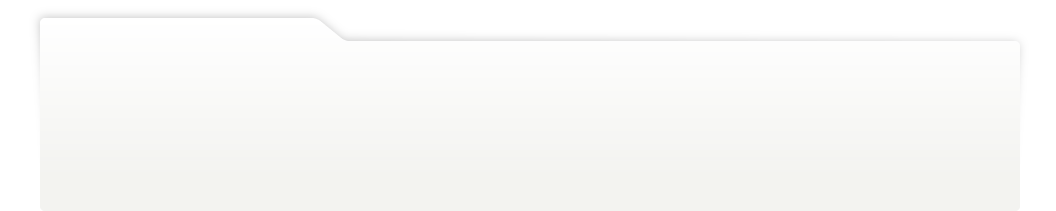
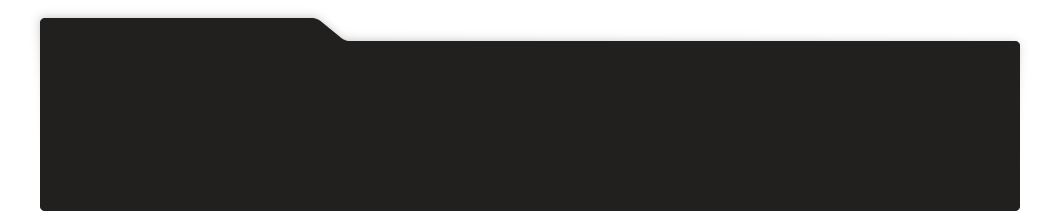
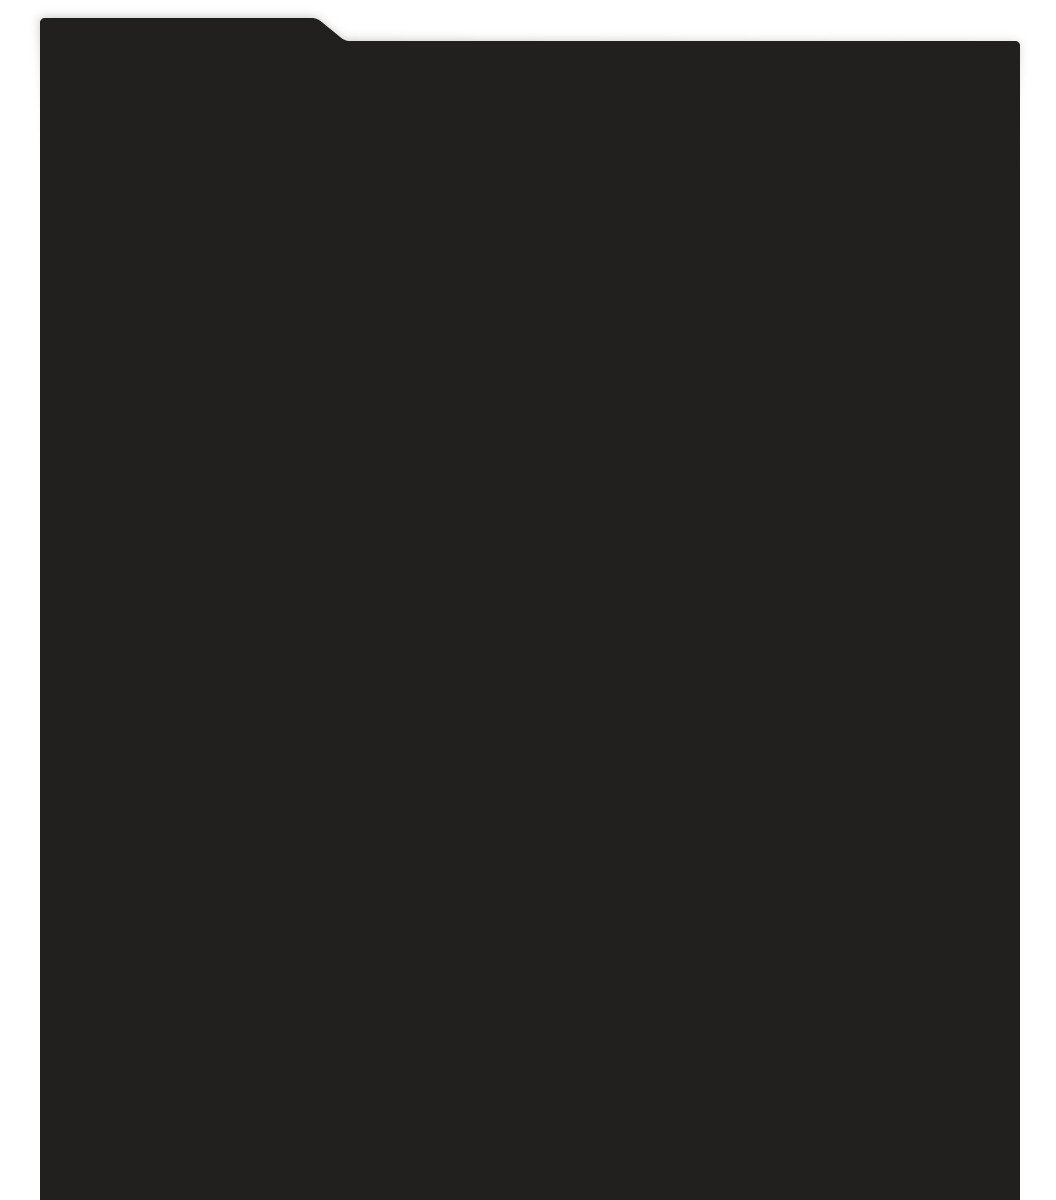
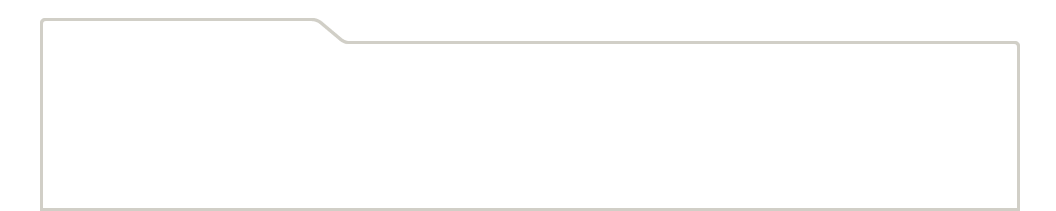
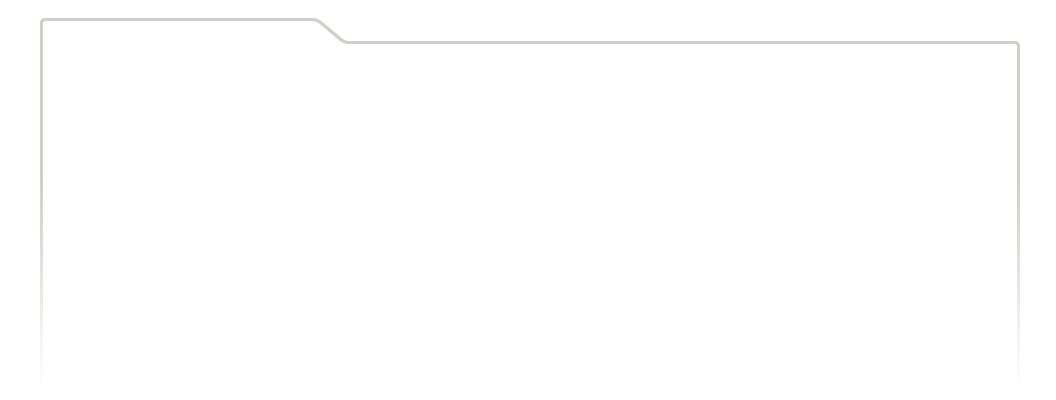
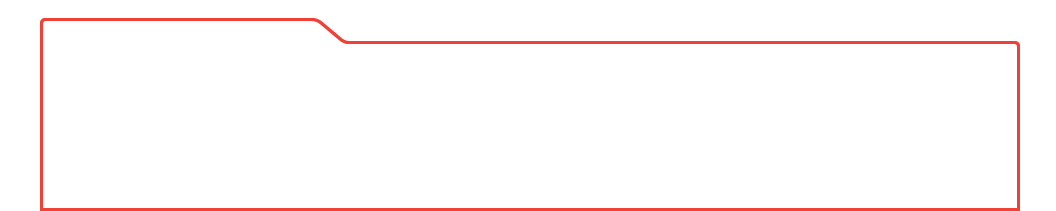
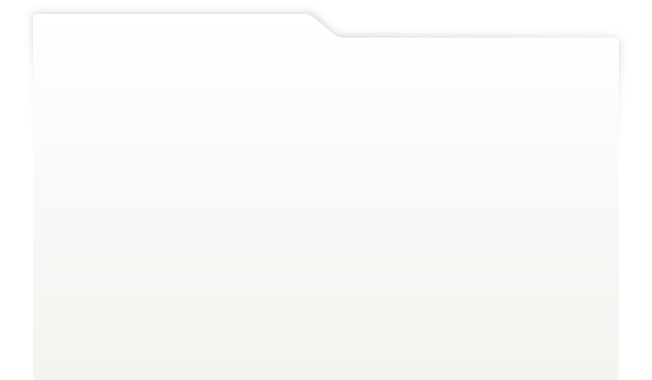
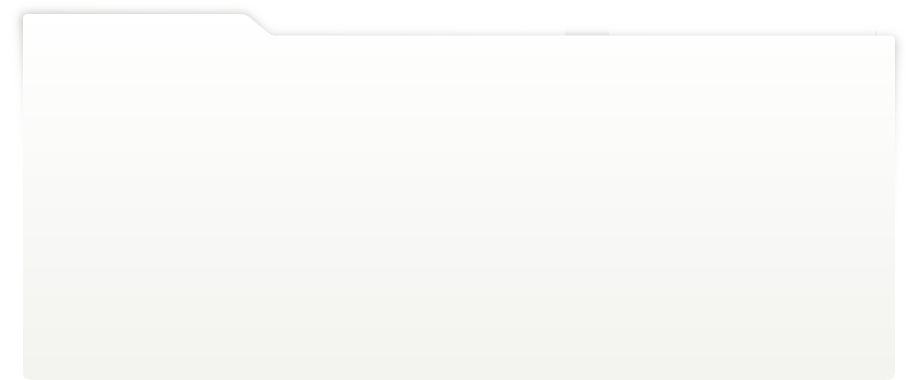
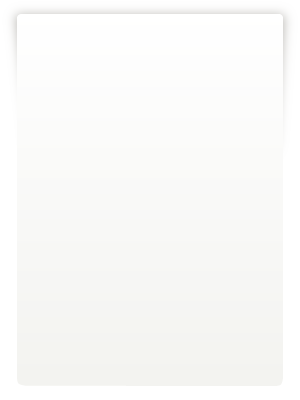
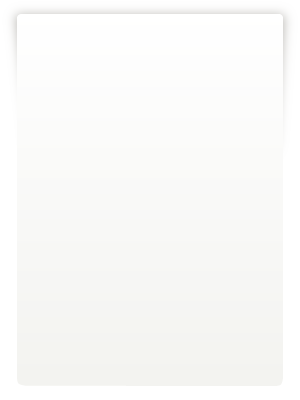
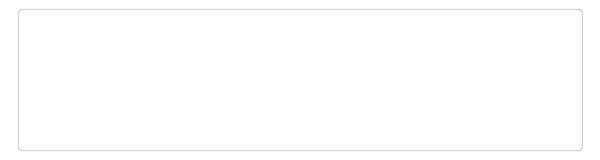
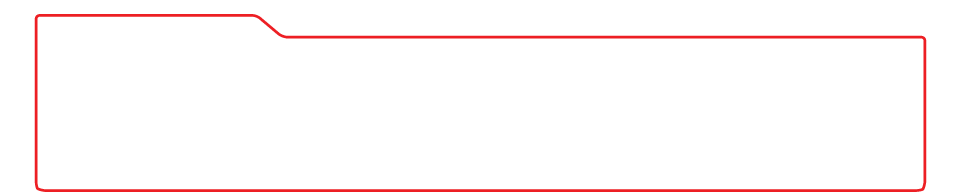
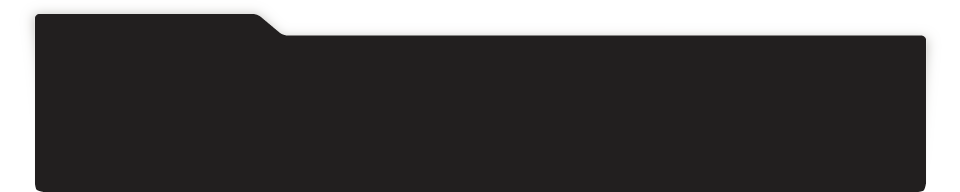
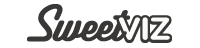
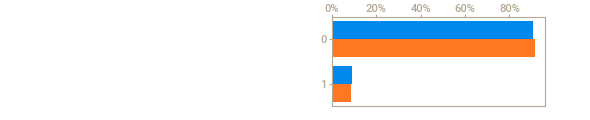
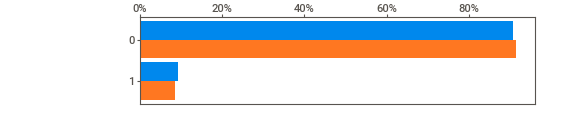
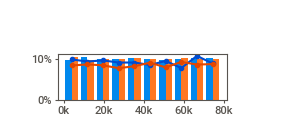
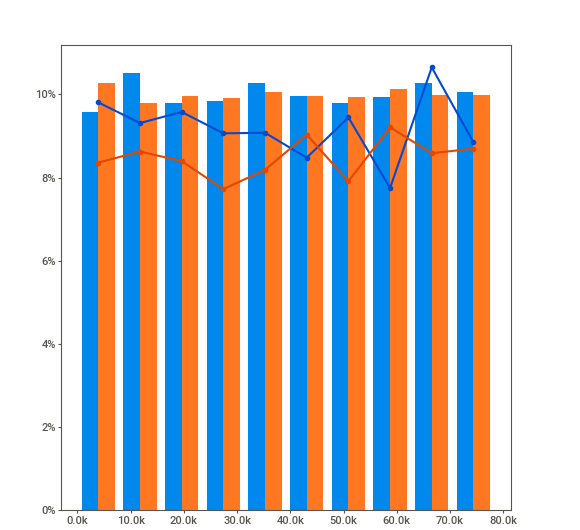
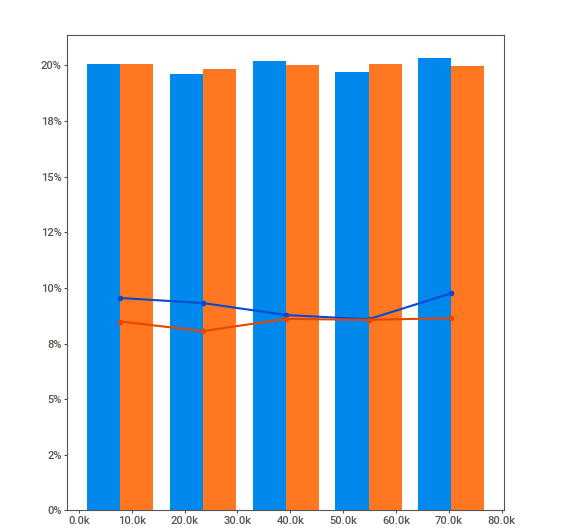
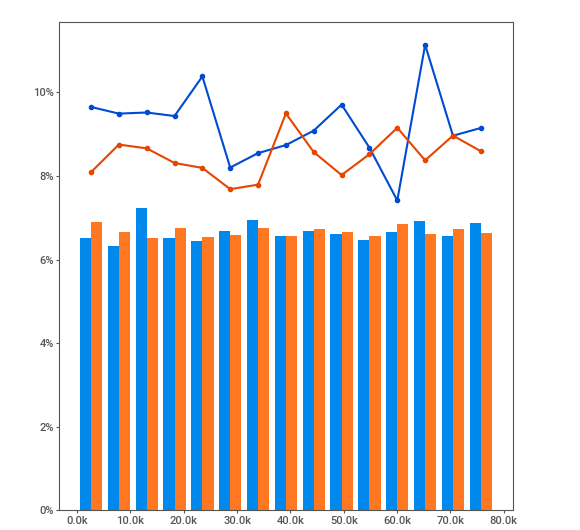
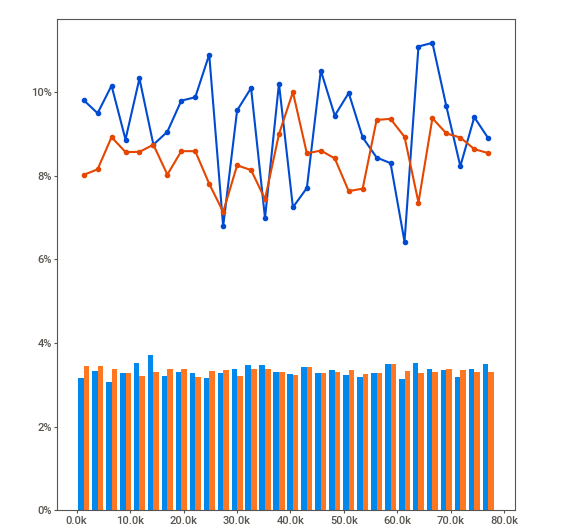
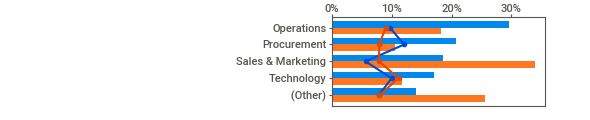
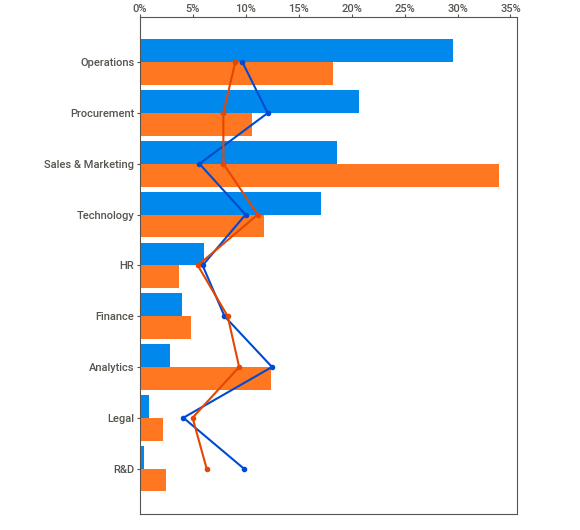
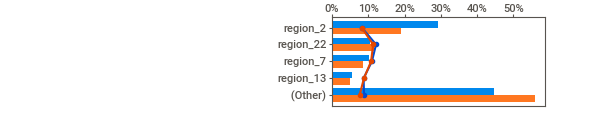
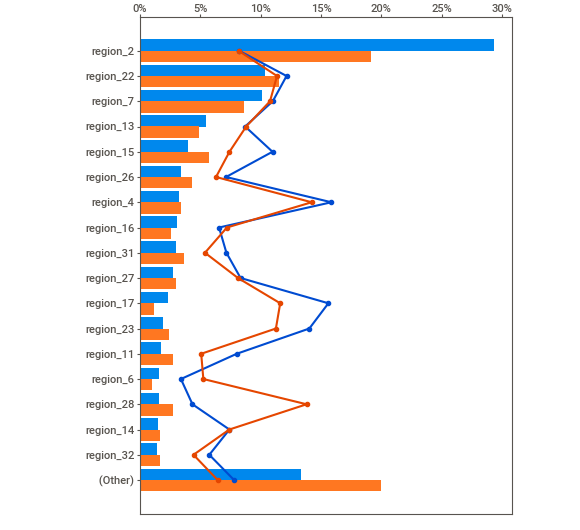
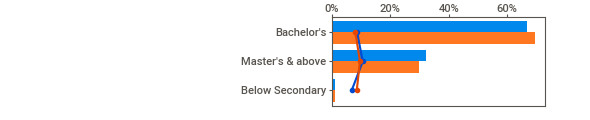
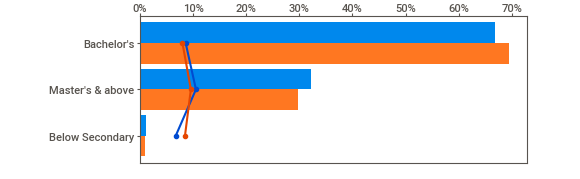
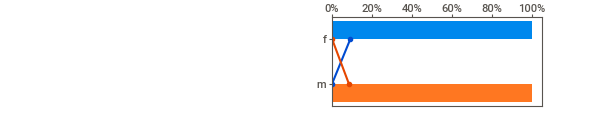
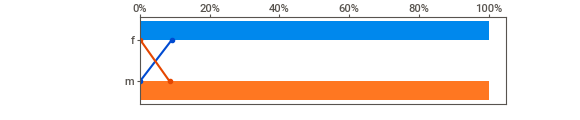
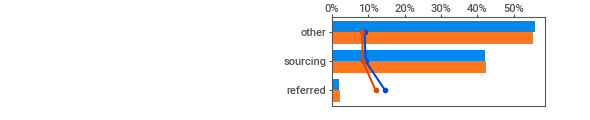
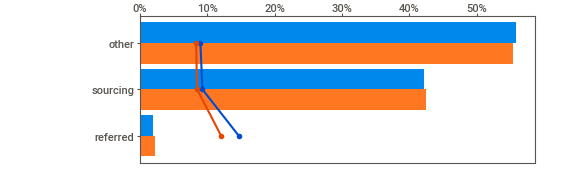
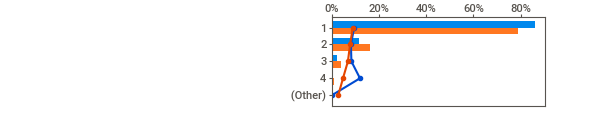
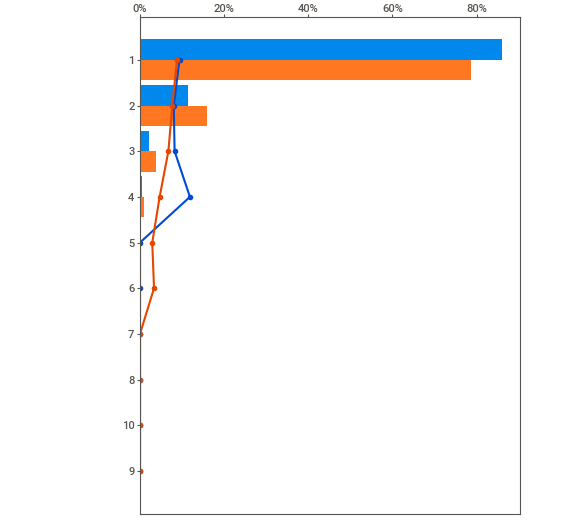
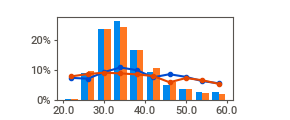
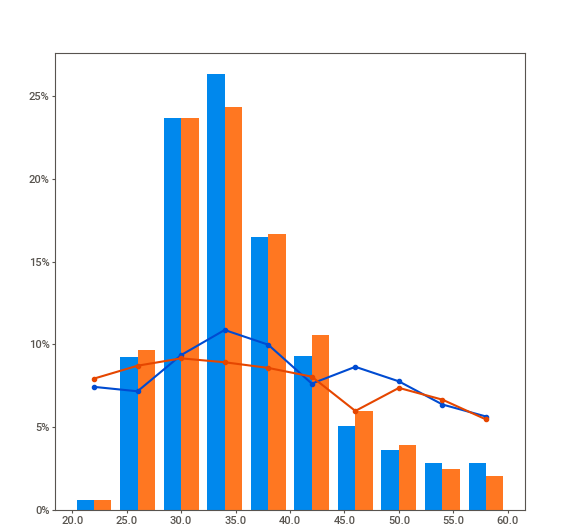
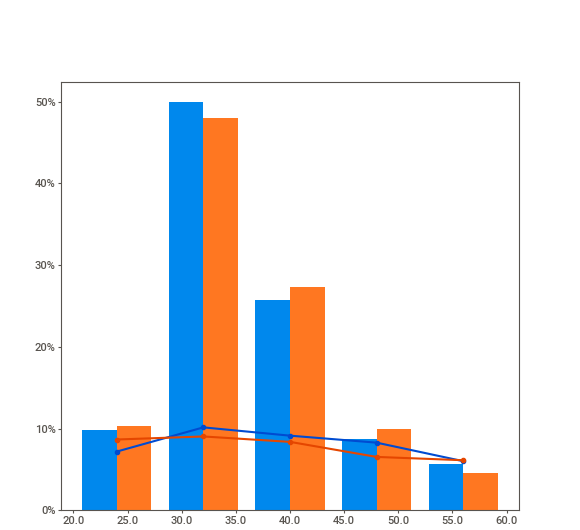
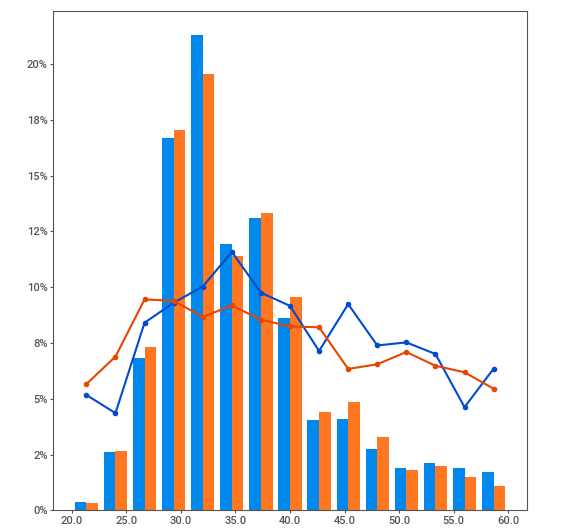
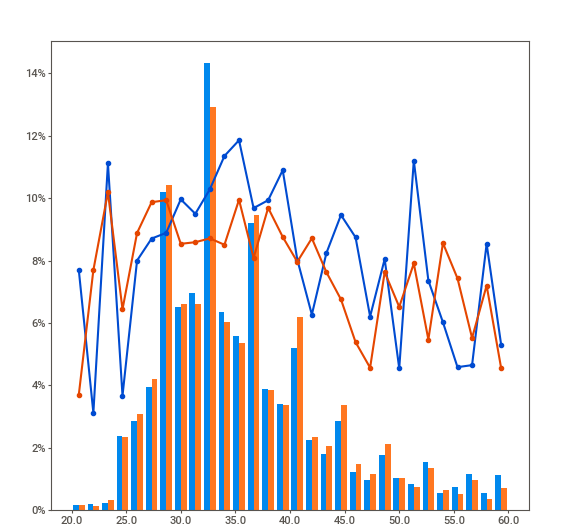
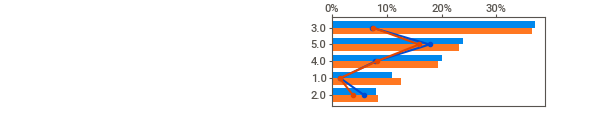
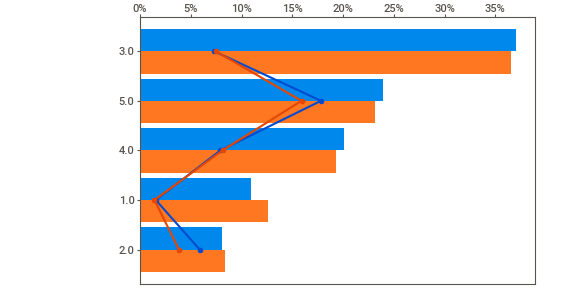
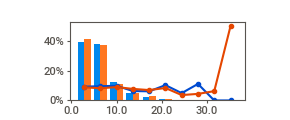
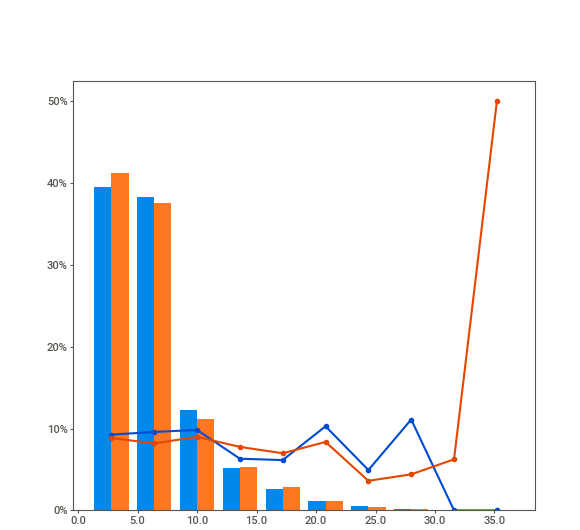
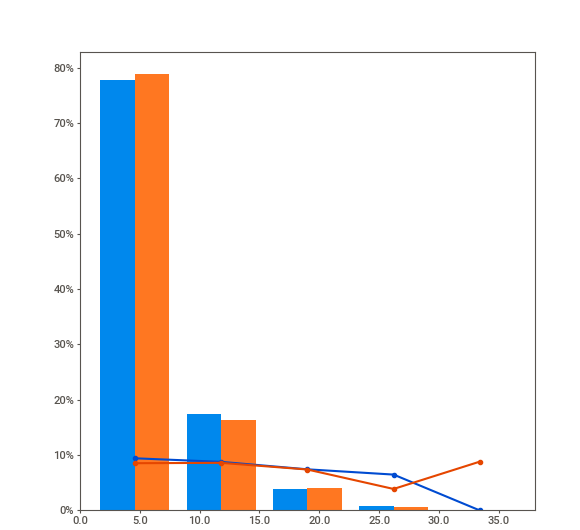
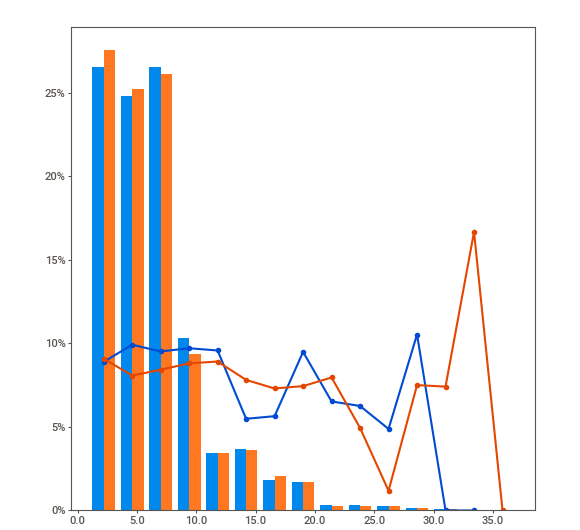
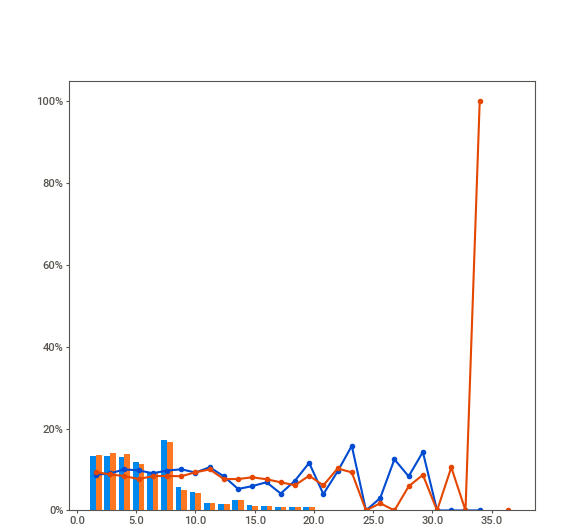
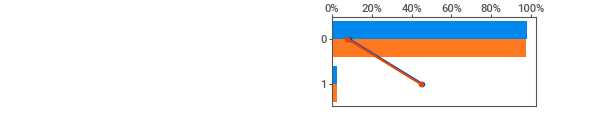
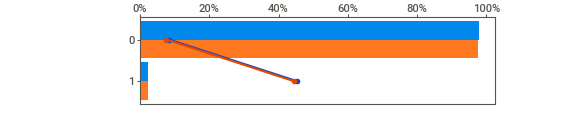
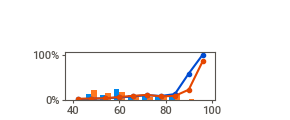
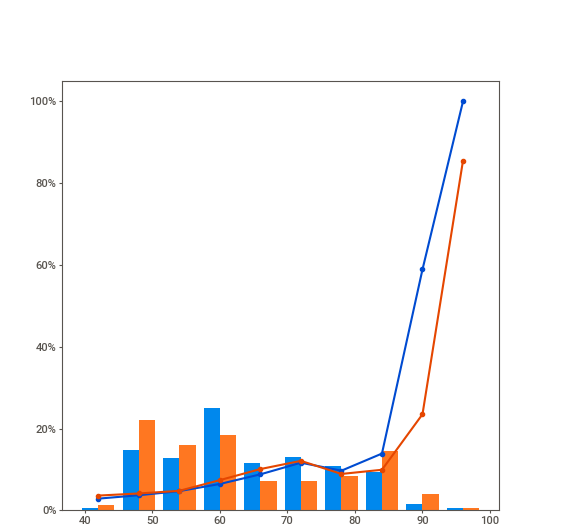
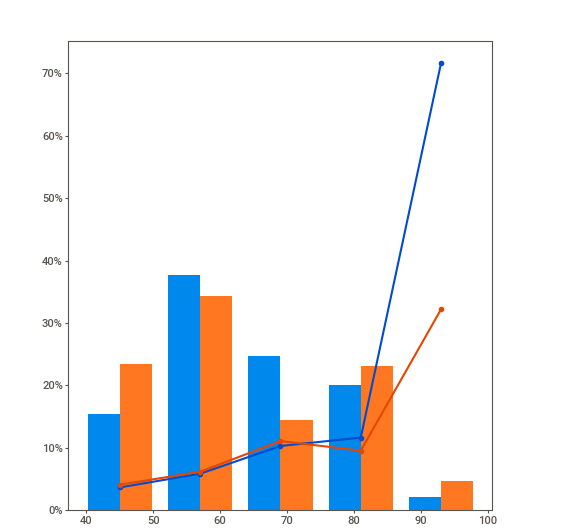
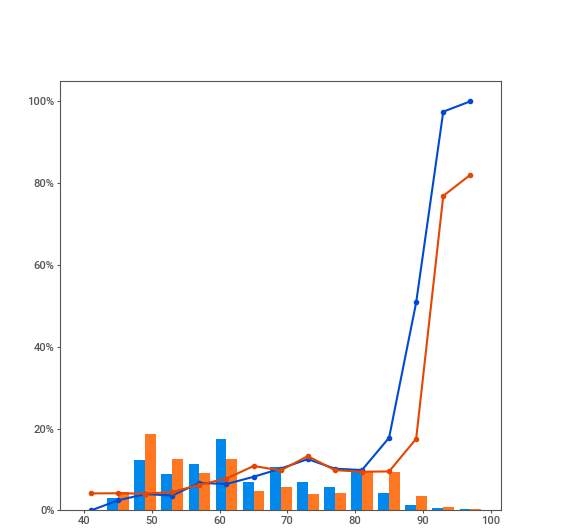
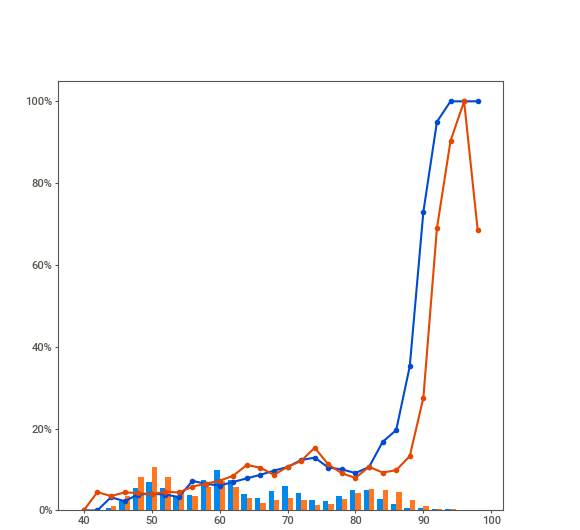
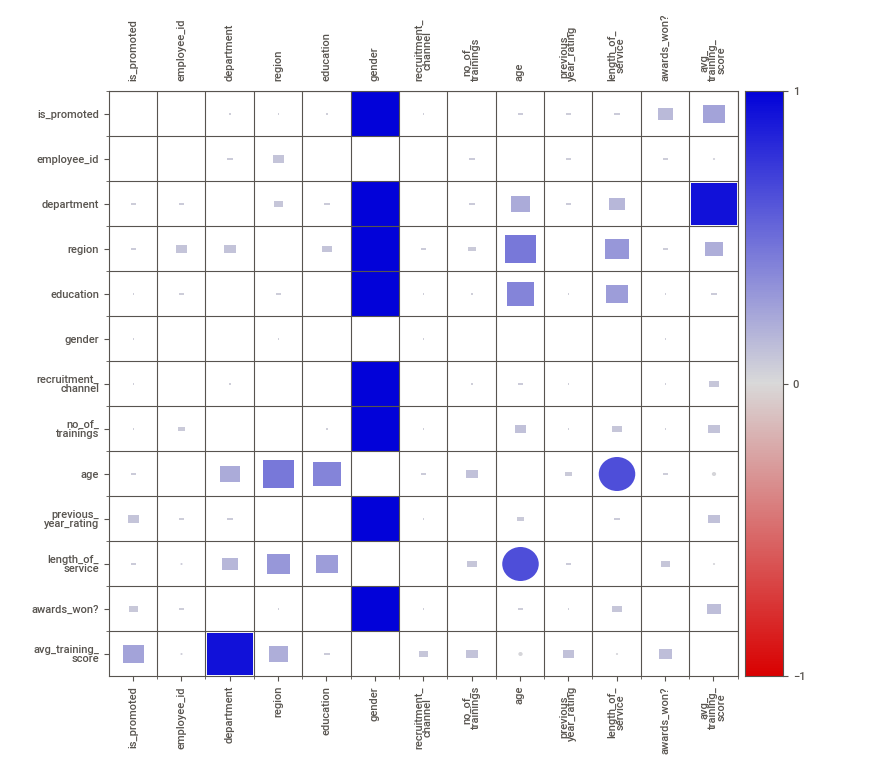
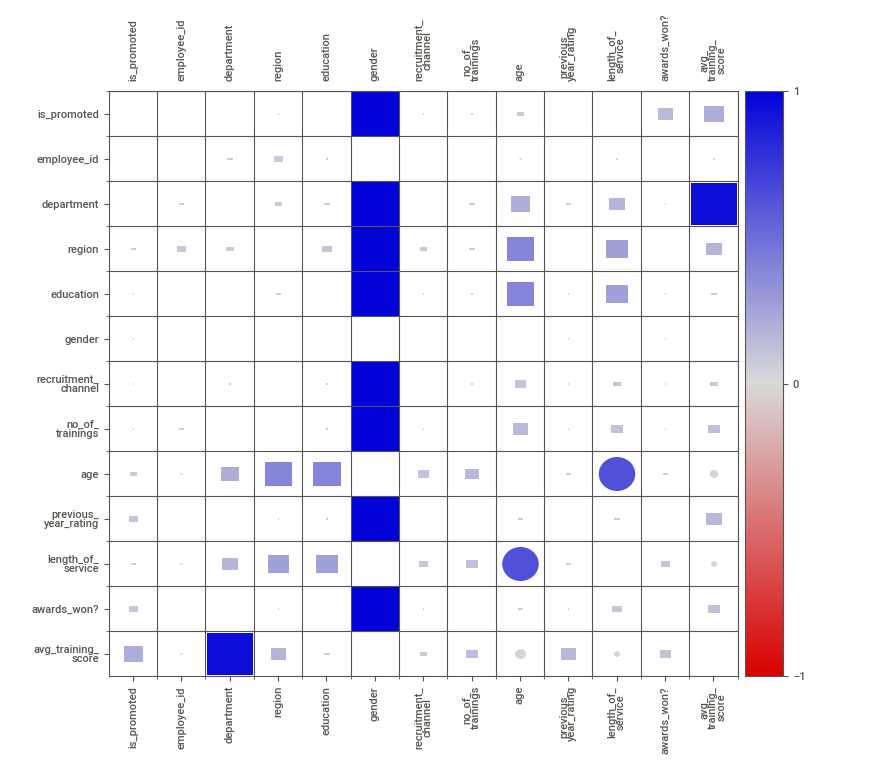

In [ ]:
import sweetviz as sv
from IPython.display import HTML, display

# Asegura nombres sin espacios
info.columns = info.columns.str.strip()

# 1) Copia sin NaN SOLO para Sweetviz
info_sv = info.dropna().copy()

# 2) Quitar columnas creadas
cols_drop = [c for c in ["gender_bool", "gender_group", "gender_group_bool"] if c in info_sv.columns]
if cols_drop:
    info_sv = info_sv.drop(columns=cols_drop)

# 3) Subconjuntos por gender (columna original: 'f' / 'm')
df_f = info_sv.loc[info_sv["gender"] == "f"].reset_index(drop=True)
df_m = info_sv.loc[info_sv["gender"] == "m"].reset_index(drop=True)

print("Female:", df_f.shape, " Male:", df_m.shape)

# 4) Sweetviz compare
report = sv.compare(
    [df_f, "Female"],
    [df_m, "Male"],
    target_feat="is_promoted"
)

report.show_html("sweetviz_gender.html", open_browser=False)
display(HTML(open("sweetviz_gender.html", "r", encoding="utf-8").read()))

In [ ]:
info.columns

Index(['department', 'region', 'education', 'gender', 'recruitment_channel',
       'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service',
       'awards_won?', 'avg_training_score', 'is_promoted', 'gender_bool',
       'gender_group'],
      dtype='object')

4. Elimina los registros con información faltante (`NaN`) y la columna `employee_id` por no tener aportación en la predicción.

In [ ]:
# Eliminar faltantes
info.columns = info.columns.str.strip()

info = info.dropna().drop(columns=["employee_id"])
info.shape,info.head()

In [ ]:
# Elimina la columna employee_id

5. Codifica las variables categóricas de info con `LabelEncoder`.

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Codifica las variables categóricas
from sklearn.preprocessing import LabelEncoder

info_enc = info.copy()

cat_cols = info_enc.select_dtypes(include =["object"]).columns

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    info_enc[col] = le.fit_transform(info_enc[col])
    encoders[col] = le

info_enc.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted,gender_bool,gender_group
0,7,31,2,0,2,1,35,5.0,8,0,49,0,False,0
1,4,14,0,1,0,1,30,5.0,4,0,60,0,True,1
2,7,10,0,1,2,1,34,3.0,7,0,50,0,True,1
3,7,15,0,1,0,2,39,1.0,10,0,50,0,True,1
4,8,18,0,1,0,1,45,3.0,2,0,73,0,True,1


6. Divide la matriz en conjuntos de entrenamiento y prueba (80:20), utilizando el parámetro `random_state=1` para garantizar reproducibilidad.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Dividir el conjunto dataframe info para obtener: train y test
# Separar variables predictoras y objetivo
X = info_enc.drop(columns=["is_promoted"])
y = info_enc["is_promoted"]

# Split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1
)

# Verificación
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((38928, 13), (9732, 13), (38928,), (9732,))

7. Observa la distribución de la variable objetivo `is_promoted`. En caso de que las clases estén desbalanceadas, realiza over_sampling con el método `SMOTE()`.

In [ ]:
# Observar la distribución
y_train.value_counts()

,count
is_promoted,
0,35552
1,3376


In [ ]:
# Separar los predictores (X) y la variable de salida (y)
y_train.value_counts(normalize=True)

,proportion
is_promoted,
0,0.913276
1,0.086724


In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
# Aplicar SMOTE al conjunto de entrenamiento (train[X], train[y])

8. Configura el autoaprendizaje de PyCaret asegurándote de usar `preprocess=False` para no aplicar ninguna operación adicional al conjunto.

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=1)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
y_train_sm.value_counts()



,count
is_promoted,
0,35552
1,35552


In [ ]:
locals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'content', 'f', '_i2', '_i3', '_i4', '_i5', 'pd', '_i6', 'info', '_6', '_i7', 'ProfileReport', '_i8', 'display', 'var_desc', 'profile', '_i9', 'sv', 'HTML', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', 'info_sv', '_i16', '_i17', '_i18', '_i19', '_i20', '_i21', '_i22', 'df_f', 'df_m', '_i23', '_i24', '_i25', 'cols_drop', '_i26', 'report', '_i27', '_i28', '_i29', '_i30', '_30', '_i31', 'LabelEncoder', '_i32', '_i33', 'info_enc', '_i34', '_i35', 'cat_cols', 'encoders', 'col', 'le', '_35', '_i36', 'train_test_split', '_i37', 'X', 'y', 'X_train', 'X_test', 'y_train', 'y_test', '_37', '_i38', '_38', '_i39', '_39', '_i40', '_i41', '_41', '_i42', 'ClassificationExperiment', 'setup', 'create_model', 'compare_models', 'ensemble_model', 'tune_model', 'blend_models', 'stack_models'

In [ ]:
# Configurar y ejecutar el autoaprendizaje
from pycaret.classification import *
train_df = X_train_sm.copy()
train_df["is_promoted"] = y_train_sm

# Configuración de PyCaret (AUTO-ML)
setup(
    data=train_df,
    target="is_promoted",
    preprocess=False,
    session_id=1,
    verbose=False
)

9. Optimiza el mejor modelo `tune_model()` con la métrica `accuracy`.

In [ ]:
# Optimizar el mejor modelo
best_model = compare_models(sort="Accuracy")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9502,0.9848,0.9351,0.9642,0.9494,0.9004,0.9008,4.5960
et,Extra Trees Classifier,0.9501,0.9856,0.9371,0.9622,0.9495,0.9003,0.9006,4.4370
xgboost,Extreme Gradient Boosting,0.9223,0.9739,0.8780,0.9633,0.9187,0.8446,0.8479,0.4910
dt,Decision Tree Classifier,0.9166,0.9169,0.9359,0.9012,0.9182,0.8332,0.8339,0.1580
lightgbm,Light Gradient Boosting Machine,0.9131,0.9690,0.8578,0.9645,0.9080,0.8261,0.8313,1.7630
gbc,Gradient Boosting Classifier,0.8837,0.9494,0.8255,0.9342,0.8765,0.7673,0.7726,4.3520
knn,K Neighbors Classifier,0.8616,0.9502,0.9867,0.7893,0.8770,0.7232,0.7469,0.8350
ada,Ada Boost Classifier,0.8595,0.9274,0.7970,0.9109,0.8501,0.7190,0.7248,1.0700
ridge,Ridge Classifier,0.7318,0.8219,0.6678,0.7659,0.7135,0.4637,0.4675,0.0530
lda,Linear Discriminant Analysis,0.7318,0.8219,0.6677,0.7660,0.7135,0.4637,0.4675,0.0730


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [ ]:
tuned_model = tune_model(best_model, optimize = "Accuracy")

pull()

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8001,0.8831,0.7710,0.8187,0.7941,0.6002,0.6013
1,0.8094,0.8932,0.7782,0.8299,0.8032,0.6187,0.6199
2,0.7983,0.8866,0.7681,0.8174,0.7920,0.5965,0.5976
3,0.8019,0.8824,0.7596,0.8297,0.7931,0.6038,0.6059
4,0.8033,0.8851,0.7725,0.8231,0.7970,0.6066,0.6077
5,0.7872,0.8765,0.7420,0.8157,0.7771,0.5744,0.5768
6,0.7904,0.8820,0.7597,0.8095,0.7838,0.5809,0.5820
7,0.8093,0.8839,0.7774,0.8305,0.8031,0.6187,0.6199
8,0.8025,0.8794,0.7750,0.8202,0.7969,0.6050,0.6059


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8001,0.8831,0.7710,0.8187,0.7941,0.6002,0.6013
1,0.8094,0.8932,0.7782,0.8299,0.8032,0.6187,0.6199
2,0.7983,0.8866,0.7681,0.8174,0.7920,0.5965,0.5976
3,0.8019,0.8824,0.7596,0.8297,0.7931,0.6038,0.6059
4,0.8033,0.8851,0.7725,0.8231,0.7970,0.6066,0.6077
5,0.7872,0.8765,0.7420,0.8157,0.7771,0.5744,0.5768
6,0.7904,0.8820,0.7597,0.8095,0.7838,0.5809,0.5820
7,0.8093,0.8839,0.7774,0.8305,0.8031,0.6187,0.6199
8,0.8025,0.8794,0.7750,0.8202,0.7969,0.6050,0.6059


10. Utiliza `evaluate_model()` para mostrar la interfaz de usuario con detalles del modelo optimizado y verifica las métricas `predict_model() `con el conjunto de prueba.

In [ ]:
# Detalles del modelo
evaluate_model(tuned_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
# Verifica las métricas
test_df = X_test.copy()
test_df["is_promoted"] = y_test

pred_test = predict_model(tuned_model, data=test_df)
pred_test.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9079,0.7703,0.2991,0.4638,0.3636,0.3165,0.3254


,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,gender_bool,gender_group,is_promoted,prediction_label,prediction_score
35377,7,11,2,1,2,1,42,4.0,5,0,49,True,1,0,0,0.980
52532,4,11,0,1,0,1,30,1.0,2,0,55,True,1,0,0,0.980
29470,8,11,0,1,2,1,27,5.0,5,0,80,True,1,0,1,0.830
21740,4,19,0,0,0,1,35,1.0,3,0,55,False,0,0,0,1.000
15769,7,20,0,1,2,1,36,3.0,4,0,49,True,1,0,0,0.995
